# 02 · Target Engineering — Defining a "Good" vs. "Bad" Client
### Credit Risk Analysis

**Notebook 2 of 6.** In notebook 01 we profiled the raw data and discovered the
single most important fact about this project: **there is no target column**. The
data tells us *who applied* and *how they repaid month to month*, but never
labels anyone as a default. Before any analysis of "what drives default" is
possible, we have to **define default ourselves**.

This notebook does exactly that. It is the most judgment-heavy step in the whole
project — and in a real credit team it would be signed off by risk management,
because where you draw the "bad" line changes every downstream number.

## Why the label has to be engineered (and why that's realistic)

Production credit data almost never arrives with a tidy `defaulted: yes/no`
flag. What a lender actually has is a **repayment history** — and "default" is a
*policy definition* layered on top of it, not a fact in the data. Different
institutions and regulators draw the line differently (30 vs. 60 vs. 90 days
past due; "ever delinquent" vs. "delinquent within 12 months").

So engineering the label is not busywork — it is a genuine analytical decision
with three parts we have to make explicit:

1. **How bad is "bad"?** Which delinquency severity counts (the days-past-due
   threshold).
2. **Over what window?** Judged over a client's whole history, or a fixed
   performance window so everyone is compared fairly (this is the idea behind
   **vintage analysis**).
3. **What's the grain?** The history is monthly, but we predict one outcome per
   client — so the monthly records must be collapsed to a single label per ID.

We work through each below, show how sensitive the result is to these choices,
and then commit to a documented definition.

## 1. Setup and load the repayment history

**What:** Import libraries and load `credit_record.csv` — the monthly repayment
table that is the raw material for the label.

**Why:** Target engineering happens almost entirely inside `credit_record`; the
applicant table only comes in at the end, when we attach the finished label to
each applicant's features. Loading just the credit table first keeps this step
focused.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RAW_DIR = "../data/raw"
credit = pd.read_csv(f"{RAW_DIR}/credit_record.csv")
print(f"credit_record: {credit.shape[0]:,} rows x {credit.shape[1]} columns")
print(f"Distinct clients: {credit['ID'].nunique():,}")
credit.head()

credit_record: 1,048,575 rows x 3 columns
Distinct clients: 45,985


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


## 2. Decode the `STATUS` codes into delinquency severity

**What:** Map the raw `STATUS` codes to an ordered, human-readable severity and a
numeric "days past due" tier so we can reason about thresholds.

**Why:** The codes mix two ideas — *delinquency buckets* (`0`–`5`) and
*non-delinquent states* (`C` = paid off, `X` = no loan). To define "bad" by a
days-past-due threshold, we need the codes on a single ordered scale. Mapping
them once, up front, makes every later rule (30+, 60+, 90+) a simple comparison.

| Code | Meaning | Max days past due |
|------|---------|-------------------|
| `X` | No loan that month | — (not delinquent) |
| `C` | Paid off that month | 0 (not delinquent) |
| `0` | 1–29 days past due | 29 |
| `1` | 30–59 days past due | 59 |
| `2` | 60–89 days past due | 89 |
| `3` | 90–119 days past due | 119 |
| `4` | 120–149 days past due | 149 |
| `5` | 150+ / write-off | 150+ |

In [2]:
# Numeric days-past-due tier for each status (C and X are non-delinquent -> 0)
dpd_tier = {"X": 0, "C": 0, "0": 0, "1": 30, "2": 60, "3": 90, "4": 120, "5": 150}
credit["dpd"] = credit["STATUS"].map(dpd_tier)

# Quick sanity check that every status mapped
assert credit["dpd"].notna().all(), "Unmapped STATUS value found!"
print("All STATUS codes mapped to a days-past-due tier.")
credit[["STATUS", "dpd"]].drop_duplicates().sort_values("dpd")

All STATUS codes mapped to a days-past-due tier.


,STATUS,dpd
0,X,0
1,0,0
4,C,0
150,1,30
8911,2,60
8912,3,90
39164,4,120
46448,5,150


## 3. Each client has a different length of history

**What:** Measure how many months of history we have per client, and compute each
record's **account age** ("months on book") = how many months after the client's
first record it occurred.

**Why:** This is the crux of the fairness problem that **vintage analysis**
solves. A client we have observed for 50 months has far more chances to hit a bad
status than one we have observed for 5 months — purely because of observation
time, not because they are riskier. If we ignore this, "bad" partly measures *how
long we watched someone*. Quantifying the spread of history lengths tells us
whether a fixed performance window is worth imposing.

In [3]:
hist_len = credit.groupby("ID")["MONTHS_BALANCE"].agg(
    n_months="count", first_month="min", last_month="max"
)
print("Months of history per client:")
print(hist_len["n_months"].describe().round(1))

# Account age (months on book) for every record
credit = credit.merge(hist_len[["first_month"]], on="ID", how="left")
credit["months_on_book"] = credit["MONTHS_BALANCE"] - credit["first_month"]
print(f"\nAccount age ranges from {credit['months_on_book'].min():.0f} "
      f"to {credit['months_on_book'].max():.0f} months on book.")

Months of history per client:
count   45,985.00
mean        22.80
std         15.50
min          1.00
25%         10.00
50%         19.00
75%         34.00
max         61.00
Name: n_months, dtype: float64



Account age ranges from 0 to 60 months on book.


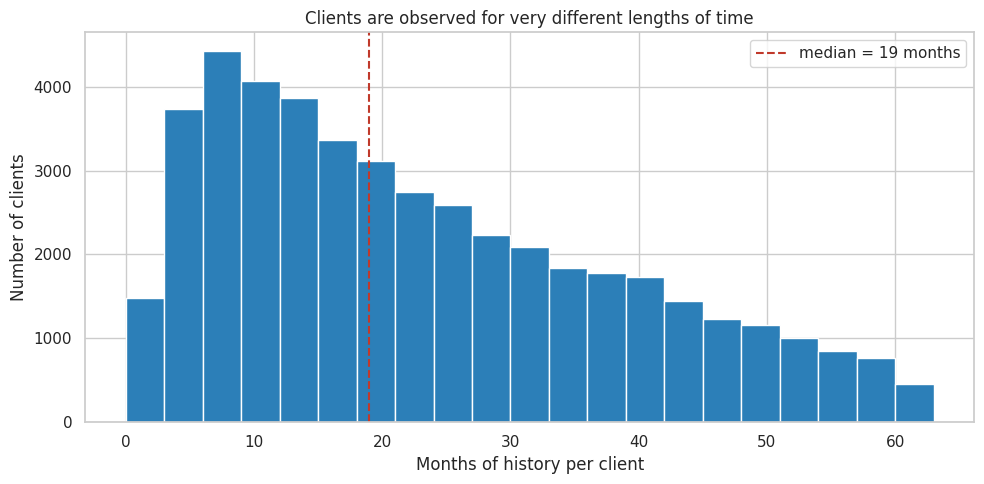

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(hist_len["n_months"], bins=range(0, 65, 3), color="#2c7fb8", edgecolor="white")
ax.axvline(hist_len["n_months"].median(), color="#c0392b", linestyle="--",
           label=f"median = {hist_len['n_months'].median():.0f} months")
ax.set_xlabel("Months of history per client")
ax.set_ylabel("Number of clients")
ax.set_title("Clients are observed for very different lengths of time")
ax.legend()
plt.tight_layout()
plt.savefig("../visualizations/02_history_length.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. How sensitive is the "bad rate" to where we draw the line?

**What:** Compute the client-level **bad rate** under three common
days-past-due thresholds — *ever 30+*, *ever 60+*, and *ever 90+ DPD* — where a
client is "bad" if **any** month in their history reached that severity.

**Why:** Before committing, we should *see* how much the choice matters. A looser
threshold (30+) labels more clients bad — more positives to learn from, but
noisier, since briefly being a month late is common and weakly linked to true
default. A stricter threshold (90+) is cleaner but rarer, leaving very few
positives. Showing the trade-off makes the final choice defensible rather than
arbitrary.

In [5]:
thresholds = {
    "ever 30+ DPD (STATUS>=1)": 30,
    "ever 60+ DPD (STATUS>=2)": 60,
    "ever 90+ DPD (STATUS>=3)": 90,
}

rows = []
client_max_dpd = credit.groupby("ID")["dpd"].max()  # worst status each client ever hit
for name, thr in thresholds.items():
    bad = (client_max_dpd >= thr)
    rows.append({"definition": name,
                 "bad_clients": int(bad.sum()),
                 "bad_rate_%": round(bad.mean() * 100, 2)})
sensitivity = pd.DataFrame(rows)
display(sensitivity)

,definition,bad_clients,bad_rate_%
0,ever 30+ DPD (STATUS>=1),5350,11.63
1,ever 60+ DPD (STATUS>=2),667,1.45
2,ever 90+ DPD (STATUS>=3),331,0.72


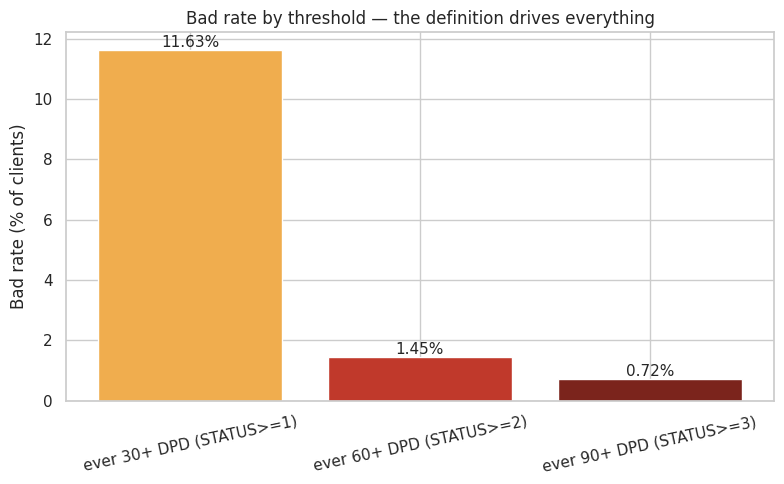

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(sensitivity["definition"], sensitivity["bad_rate_%"],
              color=["#f0ad4e", "#c0392b", "#7b241c"])
ax.set_ylabel("Bad rate (% of clients)")
ax.set_title("Bad rate by threshold — the definition drives everything")
for b, v in zip(bars, sensitivity["bad_rate_%"]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:.2f}%",
            ha="center", va="bottom", fontsize=11)
plt.xticks(rotation=12)
plt.tight_layout()
plt.savefig("../visualizations/02_threshold_sensitivity.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. The decision: bad = ever 60+ days past due

**Our definition:** a client is **bad (`1`)** if they ever reached **60+ days
past due** (`STATUS` ∈ {2, 3, 4, 5}); otherwise **good (`0`)**.

**Why 60+ DPD:**

- **Industry-standard severity.** 60–90+ DPD is a widely used default / serious-
  delinquency marker. It is severe enough to signal real credit risk, unlike
  codes `0`–`1` (under 60 days), where short, occasional lateness is common and
  weakly predictive on its own.
- **Enough signal to analyze.** The sensitivity table above shows 90+ leaves very
  few positives, which would make segment analysis unstable; 60+ keeps a workable
  number of bad clients while staying meaningfully severe.
- **Interpretable to a stakeholder.** "Ever fell two+ months behind" is an
  intuitive, defensible line for a non-technical audience.

**On the observation window:** the rigorous refinement is to require the bad
event to occur **within a fixed performance window** (e.g. the first 24 months on
book) so every client is judged over comparable time — true vintage analysis. We
compute both the simple "ever 60+" label and this windowed version below, and
compare them, so the effect of the window is visible. We use the **simple
"ever 60+" label as the project's primary target** for transparency, and keep the
windowed version documented as the more conservative alternative.

In [7]:
BAD_DPD = 60  # 60+ days past due

# --- Primary label: ever 60+ DPD over the full history ---
client_max_dpd = credit.groupby("ID")["dpd"].max()
target_ever = (client_max_dpd >= BAD_DPD).astype(int).rename("target")

# --- Alternative label: 60+ DPD within the first 24 months on book (vintage) ---
WINDOW = 24
in_window = credit[credit["months_on_book"] < WINDOW]
client_max_dpd_win = in_window.groupby("ID")["dpd"].max()
target_window = (client_max_dpd_win >= BAD_DPD).astype(int).rename("target_24m")

labels = pd.concat([target_ever, target_window], axis=1).reset_index()
labels["target_24m"] = labels["target_24m"].fillna(0).astype(int)

print(f"Primary  (ever 60+ DPD):        bad rate = {labels['target'].mean()*100:.2f}%  "
      f"({labels['target'].sum():,} bad clients)")
print(f"Vintage  (60+ DPD within 24m):  bad rate = {labels['target_24m'].mean()*100:.2f}%  "
      f"({labels['target_24m'].sum():,} bad clients)")
print(f"\nAgreement between the two labels: "
      f"{(labels['target']==labels['target_24m']).mean()*100:.1f}% of clients.")
labels.head()

Primary  (ever 60+ DPD):        bad rate = 1.45%  (667 bad clients)
Vintage  (60+ DPD within 24m):  bad rate = 1.32%  (606 bad clients)

Agreement between the two labels: 99.9% of clients.


,ID,target,target_24m
0,5001711,0,0
1,5001712,0,0
2,5001713,0,0
3,5001714,0,0
4,5001715,0,0


## 6. Attach the label to applicant features

**What:** Inner-join the engineered client label onto `application_record` so each
row becomes "applicant features + outcome". We first drop a handful of duplicate
applicant IDs to keep the join one-to-one.

**Why:** A supervised analysis needs features and a label on the same row. The
**inner** join is deliberate: only clients present in *both* tables have both, so
this is also the step that defines the true size of our analyzable dataset (we
saw in notebook 01 that only a minority of applicants have a credit history).

In [8]:
application = pd.read_csv(f"{RAW_DIR}/application_record.csv")
print(f"Applicants (raw):        {len(application):,}")
print(f"Duplicate applicant IDs: {application['ID'].duplicated().sum()}")

# Keep one row per applicant
application = application.drop_duplicates(subset="ID", keep="first")

# Join features + label (inner = only clients with both)
master = application.merge(labels, on="ID", how="inner")
print(f"\nModeling base table: {master.shape[0]:,} rows x {master.shape[1]} columns")
print(f"Match rate vs. applicants: {master.shape[0]/len(application)*100:.1f}%")

Applicants (raw):        438,557
Duplicate applicant IDs: 47

Modeling base table: 36,457 rows x 20 columns
Match rate vs. applicants: 8.3%


## 7. Final class balance

**What:** Show the class distribution of the primary target on the joined modeling
table, as a table and a chart.

**Why:** This is the number every downstream notebook plans around. As expected
for credit data, "bad" is a small minority — a **heavy class imbalance**. That
fact dictates the analysis: plain accuracy is misleading (predicting "everyone is
good" scores high while being useless), so EDA and any model will lean on
bad-*rate* comparisons across segments and on imbalance-aware metrics.

,class,count,pct
0,Good (0),35841,98.31
1,Bad (1),616,1.69


Imbalance ratio (good : bad) = 58.2 : 1


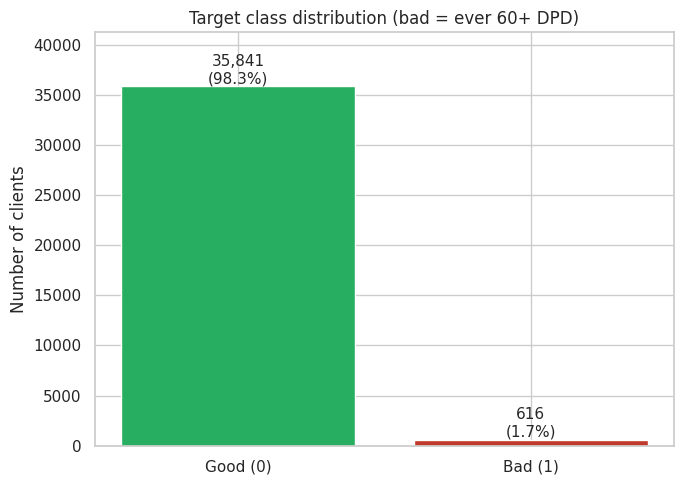

In [9]:
counts = master["target"].value_counts().sort_index()
pct = master["target"].value_counts(normalize=True).sort_index() * 100
summary = pd.DataFrame({"class": ["Good (0)", "Bad (1)"],
                        "count": counts.values, "pct": pct.values})
display(summary)
print(f"Imbalance ratio (good : bad) = {counts[0]/counts[1]:,.1f} : 1")

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(["Good (0)", "Bad (1)"], counts.values, color=["#27ae60", "#c0392b"])
for b, c, p in zip(bars, counts.values, pct.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height(), f"{c:,}\n({p:.1f}%)",
            ha="center", va="bottom", fontsize=11)
ax.set_ylabel("Number of clients")
ax.set_title("Target class distribution (bad = ever 60+ DPD)")
ax.set_ylim(0, counts.max()*1.15)
plt.tight_layout()
plt.savefig("../visualizations/02_class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Save the labelled base table

**What:** Write the joined "features + target" table to `data/processed/` as the
input for the EDA notebooks.

**Why:** Target engineering is now a solved, reproducible step. Persisting the
result means notebooks 03–05 start from a single, consistent labelled dataset
instead of re-deriving the label each time — and anyone reviewing the project can
inspect exactly what was modeled.

In [10]:
out_path = "../data/processed/credit_risk_labelled.csv"
master.to_csv(out_path, index=False)
print(f"Saved {master.shape[0]:,} labelled clients -> {out_path}")
print("Columns:", list(master.columns))

Saved 36,457 labelled clients -> ../data/processed/credit_risk_labelled.csv
Columns: ['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'target', 'target_24m']


## 9. Observations & decisions

- **The target is engineered, not given.** We defined **bad = ever 60+ days past
  due** (`STATUS` ∈ {2,3,4,5}) at the client level — a documented policy choice,
  exactly as a real credit team would make.
- **The definition drives everything.** The threshold sensitivity check showed
  the bad rate swings materially between the 30+, 60+ and 90+ definitions; 60+ is
  the balanced, industry-standard middle ground.
- **Observation time is a real confound.** Clients are watched for very different
  numbers of months, so we also built a **24-month vintage-window** label and
  compared it to the simple "ever 60+" version; they agree on the large majority
  of clients, which gives us confidence the simple label is reasonable.
- **The classes are heavily imbalanced** — bad clients are a small minority — so
  every later step uses bad-*rate* comparisons and imbalance-aware thinking, not
  raw accuracy.
- **The analyzable dataset is the join, not the full application file** — only
  clients with both features and a repayment history survive the inner join.
- **Output:** a single labelled base table saved to
  `data/processed/credit_risk_labelled.csv`.

➡️ **Next notebook (`03`):** exploratory analysis of *who* defaults — bad rates
across income, age, education, housing and employment — using this labelled table.